In [1]:
import os
import re
import h5py
import numpy as np
from collections import defaultdict
import spikeinterface.extractors as se

In [2]:
import sys
import os

# Add your script folder to Python's path
sys.path.append(r"C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion")

# Import your conversion function
import resp_to_h5_ecu_only as trodes

In [3]:
dir(trodes)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'convert_all_rec_to_h5',
 'convert_sessions',
 'h5py',
 'load_trodes_exports',
 'np',
 'os',
 'parse_fields',
 'read_trodes_dat_file',
 'write_h5']

In [4]:
session_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\1_1_RI2_f2_h_off_20260119_134817.rec"

In [5]:
analog, dio, time = trodes.load_trodes_exports(session_dir)

In [6]:
print("Analog:", analog.keys())
print("DIO:", dio.keys())
print("Time:", time.keys())

Analog: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.analog_ECU_Ain1', '1_1_RI2_f2_h_off_20260119_134817.timestamps'])
DIO: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Din1', '1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Dout1'])
Time: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.timestamps'])


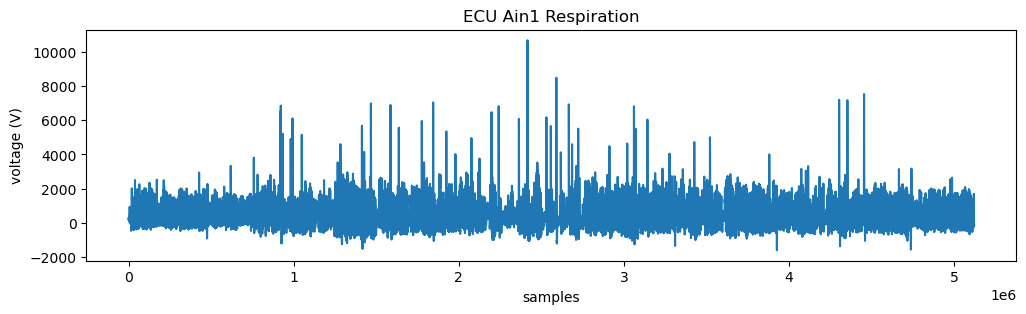

In [7]:
import matplotlib.pyplot as plt

analog_key = [k for k in analog if "Ain1" in k][0]
resp = analog[analog_key]["data"]["voltage"]

plt.figure(figsize=(12, 3))
plt.plot(resp)
plt.title("ECU Ain1 Respiration")
plt.xlabel("samples")
plt.ylabel("voltage (V)")
plt.show()

In [8]:
dio_key = [k for k in dio if "Din1" in k][0]
dio_data = dio[dio_key]["data"]

dio_data.dtype

dtype([('time', '<u4'), ('state', 'u1')])

In [9]:
times = dio_data["time"]
states = dio_data["state"]

on_times = times[states == 1]
off_times = times[states == 0]

In [10]:
out_h5 = r"D:\BLA_ChR_resp\h5\1_1_RI2_f2_h_off_20260119_134817.h5"
trodes.write_h5(out_h5, analog, dio, time)

In [11]:
import os

out_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\1_1_RI2_f2_h_off_20260119_134817.rec"
os.makedirs(out_dir, exist_ok=True)

out_h5 = os.path.join(
    out_dir,
    "1_1_RI1_f1_d_on_20260111_164638.h5"
)

trodes.write_h5(out_h5, analog, dio, time)

print("Exists:", os.path.exists(out_h5))

Exists: True


In [12]:
data_root = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1"
output_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs"

trodes.convert_sessions(data_root, output_dir)


Processing: 1_1_RI2_f2_h_off_20260119_134817.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\1_1_RI2_f2_h_off_20260119_134817.h5

Processing: 1_2_RI2_f1_a_on_20260119_170144.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\1_2_RI2_f1_a_on_20260119_170144.h5

Processing: 1_3_RI2_f2_f_on_20260119_152733.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\1_3_RI2_f2_f_on_20260119_152733.h5

Processing: 2_1_RI2_f1_a_off_20260119_173923.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\2_1_RI2_f1_a_off_20260119_173923.h5

Processing: 2_2_RI2_f2_3_on_20260119_144717.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\2_2_RI2_f2_3_on_20260119_144717.h5

Processing: 2_3_RI2_f1_d_off_20260119_160619.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\2_3_RI2_f1_d_off_20260119_160619.h5

Processing: 3_1_RI2_f2_f_off_20260119_164023.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs

In [13]:
h5_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs"

h5_files = sorted([
    os.path.join(h5_dir, f)
    for f in os.listdir(h5_dir)
    if f.endswith(".h5")
])

len(h5_files), h5_files[:3]

(23,
 ['D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_1_RI2_f2_h_off_20260119_134817.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_2_RI2_f1_a_on_20260119_170144.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_3_RI2_f2_f_on_20260119_152733.h5'])

In [15]:
import h5py

def load_ecu_h5(h5_path):
    with h5py.File(h5_path, "r") as f:
        analog = {k: f["analog"][k][()] for k in f["analog"].keys()}
        dio    = {k: f["dio"][k][()]    for k in f["dio"].keys()}
        time   = {k: f["time"][k][()]   for k in f["time"].keys()}
    return analog, dio, time

In [16]:
all_sessions = {}

for h5_path in h5_files:
    session_name = os.path.basename(h5_path).replace(".h5", "")
    analog, dio, time = load_ecu_h5(h5_path)

    all_sessions[session_name] = {
        "analog": analog,
        "dio": dio,
        "time": time
    }

print("Loaded sessions:", list(all_sessions.keys()))

Loaded sessions: ['1_1_RI2_f2_h_off_20260119_134817', '1_2_RI2_f1_a_on_20260119_170144', '1_3_RI2_f2_f_on_20260119_152733', '2_1_RI2_f1_a_off_20260119_173923', '2_2_RI2_f2_3_on_20260119_144717', '2_3_RI2_f1_d_off_20260119_160619', '3_1_RI2_f2_f_off_20260119_164023', '3_2_RI2_f1_b_on_20260119_181446', '3_3_RI2_f2_e_off_20260119_142053', '4_2_RI2_f2_f_on_20260119_133333', '4_3_RI2_f1_a_off_20260119_172948', '5_1_RI2_m2_p_off_20260119_143035', '5_2_RI2_m1_k_on_20260119_175411', '5_3_RI2_m2_m_on_20260119_161502', '6_2_RI2_m2_p_on_20260119_151011', '6_3_RI2_m1_k_on_20260119_165027', '7_1_RI2_m2_o_off_20260119_171203', '7_2_RI2_m1_i_on_20260119_140337', '7_3_RI2_m2_m_off_20260119_155215', '8_1_RI2_m1_i_off_20260119_162623', '8_2_RI2_m2_p_on_20260119_180514', '8_3_RI2_m1_j_off_20260119_150003', '9_1_RI2_m1_k_off_20260119_153823']


In [17]:
for sess, data in all_sessions.items():
    print(sess)
    print("  Analog:", data["analog"].keys())
    print("  DIO:", data["dio"].keys())
    print("  Time:", data["time"].keys())

1_1_RI2_f2_h_off_20260119_134817
  Analog: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.analog_ECU_Ain1', '1_1_RI2_f2_h_off_20260119_134817.timestamps'])
  DIO: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Din1', '1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Dout1'])
  Time: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.timestamps'])
1_2_RI2_f1_a_on_20260119_170144
  Analog: dict_keys(['1_2_RI2_f1_a_on_20260119_170144.analog_ECU_Ain1', '1_2_RI2_f1_a_on_20260119_170144.timestamps'])
  DIO: dict_keys(['1_2_RI2_f1_a_on_20260119_170144.dio_ECU_Din1', '1_2_RI2_f1_a_on_20260119_170144.dio_ECU_Dout1'])
  Time: dict_keys(['1_2_RI2_f1_a_on_20260119_170144.timestamps'])
1_3_RI2_f2_f_on_20260119_152733
  Analog: dict_keys(['1_3_RI2_f2_f_on_20260119_152733.analog_ECU_Ain1', '1_3_RI2_f2_f_on_20260119_152733.timestamps'])
  DIO: dict_keys(['1_3_RI2_f2_f_on_20260119_152733.dio_ECU_Din1', '1_3_RI2_f2_f_on_20260119_152733.dio_ECU_Dout1'])
  Time: dict_keys(['1_3_RI2_f2_f_on_20260119_152733.timestamp

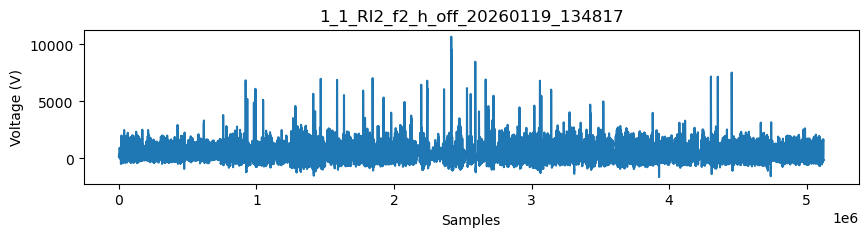

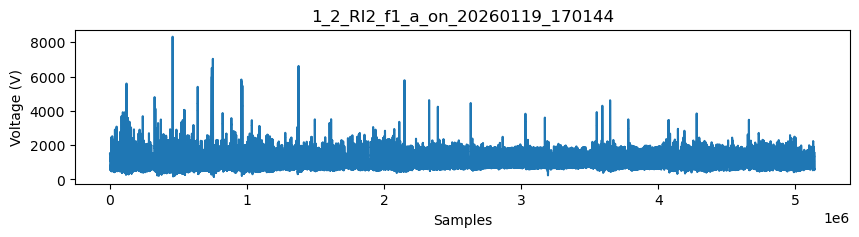

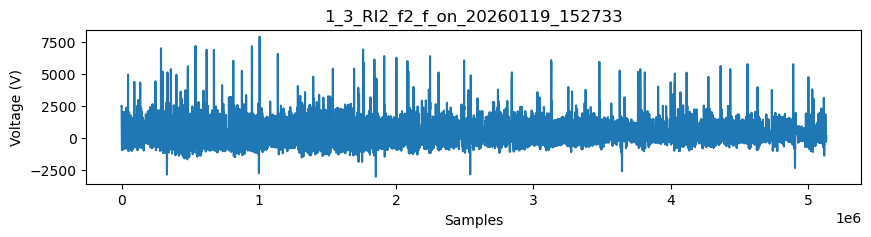

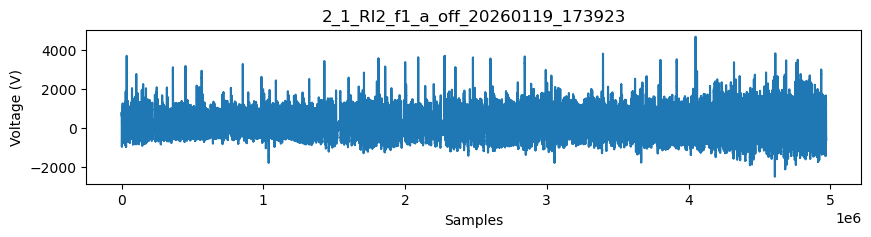

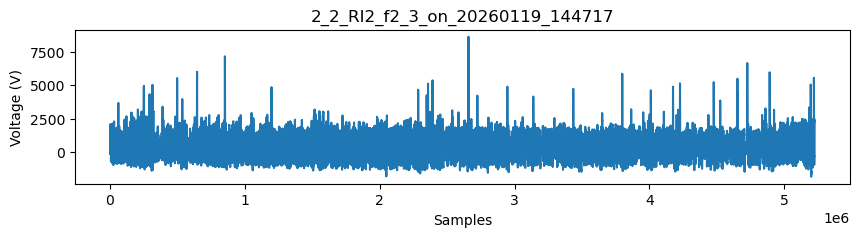

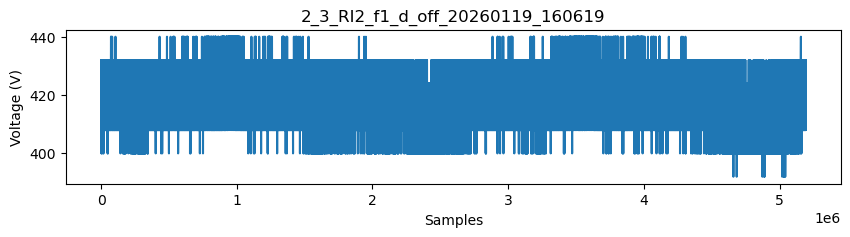

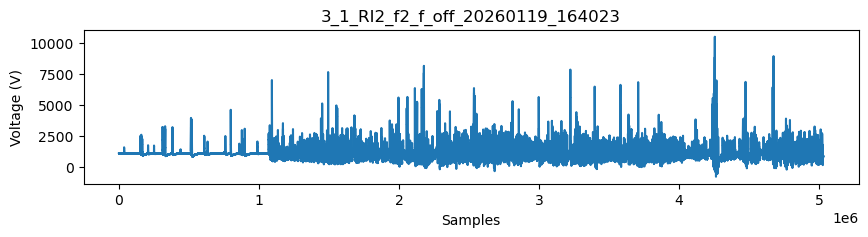

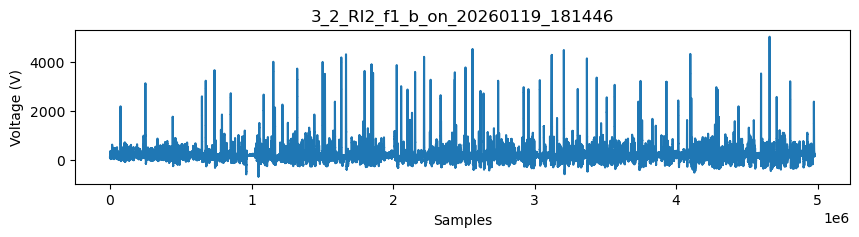

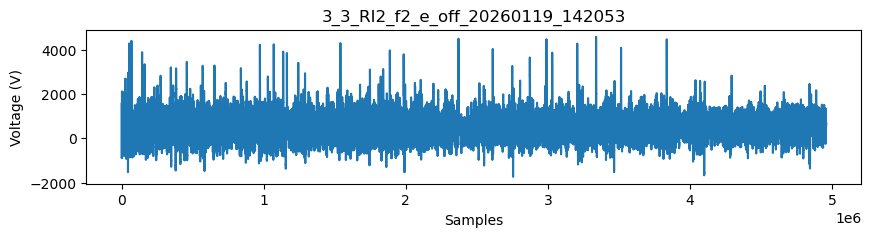

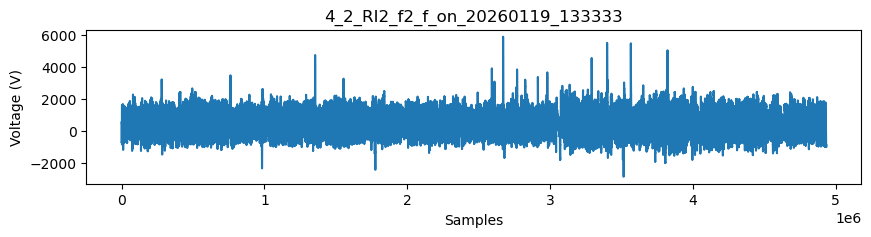

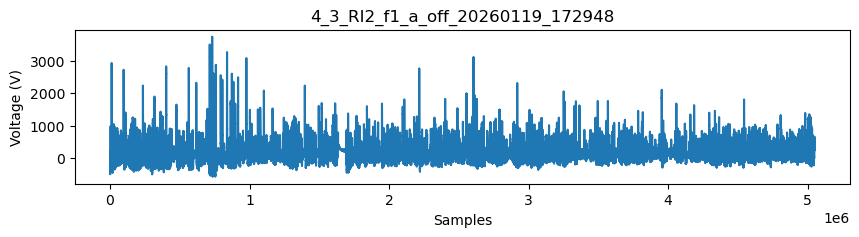

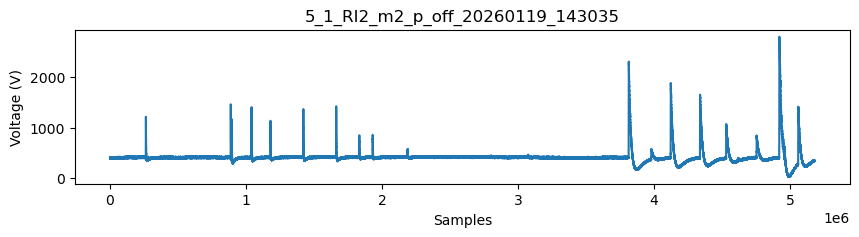

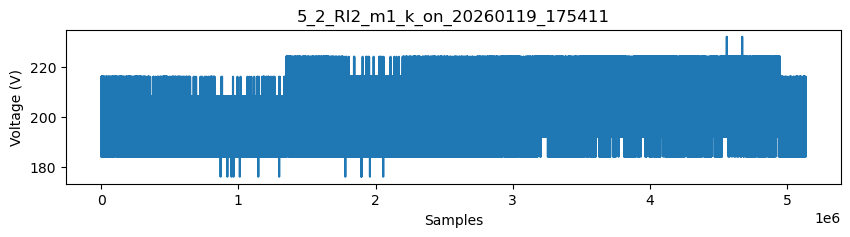

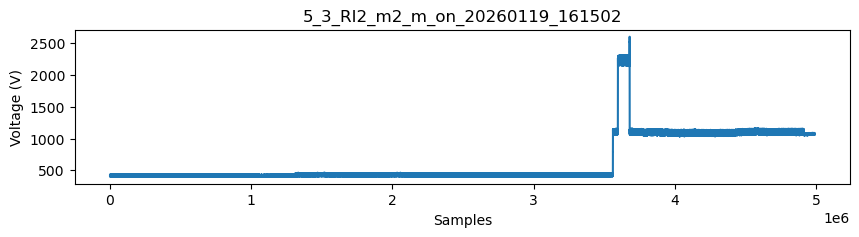

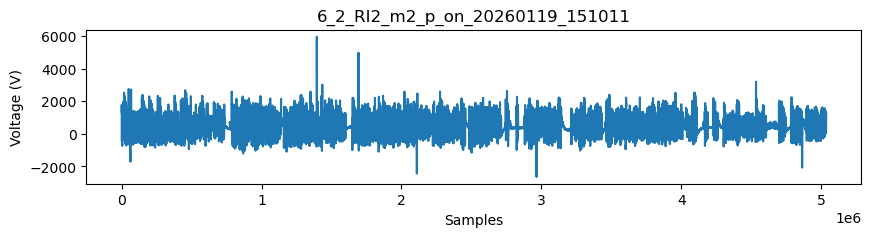

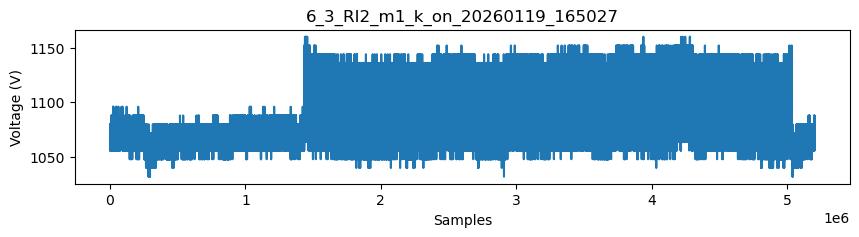

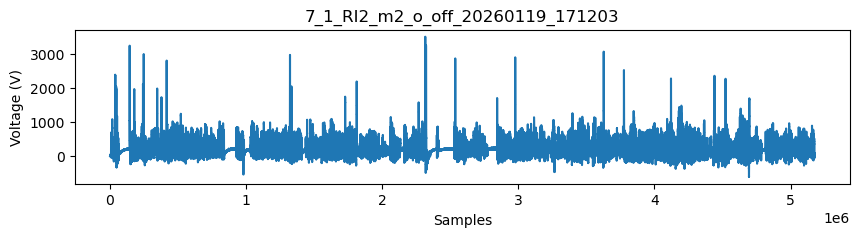

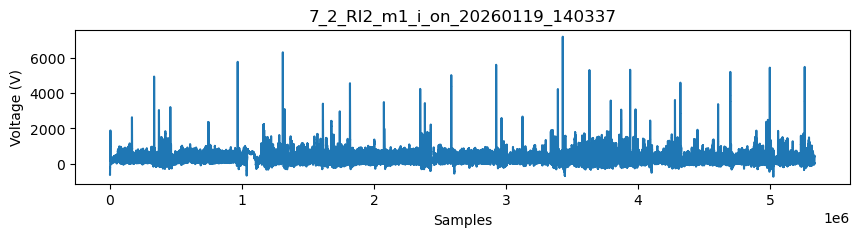

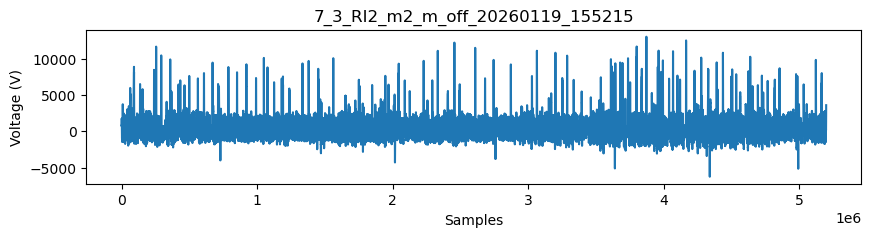

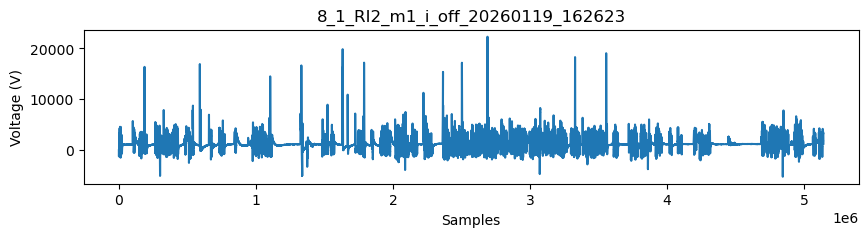

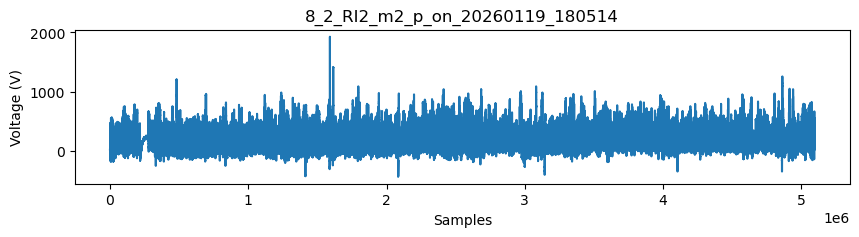

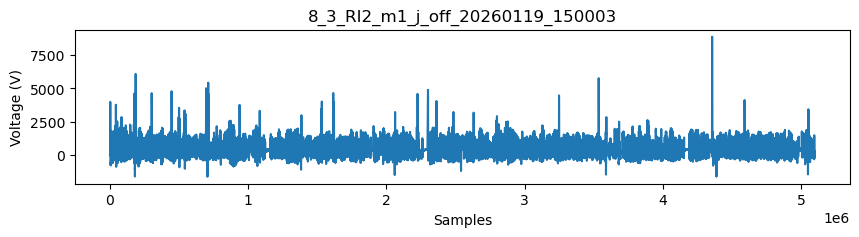

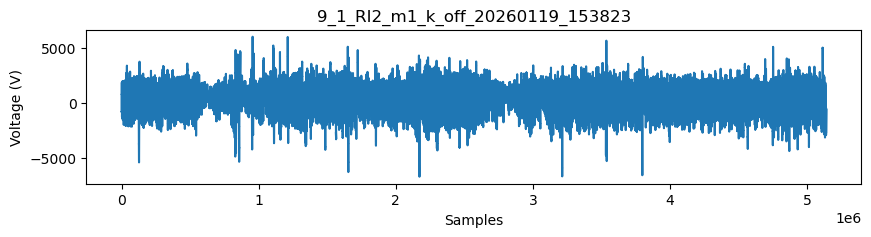

In [18]:
import matplotlib.pyplot as plt

for sess, data in all_sessions.items():
    analog = data["analog"]
    key = [k for k in analog if "Ain1" in k][0]
    resp = analog[key]["voltage"]

    plt.figure(figsize=(10, 2))
    plt.plot(resp)
    plt.title(sess)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Samples")
    plt.show()